# News Event Sweep Analysis - Exploration

Interactive exploration of data high/low sweep behavior across news events.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Load data
DATA_DIR = Path('data')
df = pd.read_parquet(DATA_DIR / 'sweep_analysis_results.parquet')
print(f"Loaded {len(df)} events")
df.head()

Loaded 1405 events


,event_type,event_datetime,release_time,data_high,data_low,range,range_pct,first_sweep,time_to_first_sweep,opposite_swept,time_to_opposite_sweep,synthetic_box_breached,first_target_hit,mae_before_reversal
0,US ISM Manufacturing PMI,2020-09-01 14:00:00+00:00,10:00,12222.75,12192.00,30.75,0.252070,high,1.0,False,NaN,True,box,2.756098
1,US ADP Non-Farm Employment Change,2020-09-02 12:15:00+00:00,08:15,12432.00,12423.00,9.00,0.072394,high,1.0,True,74.0,True,box,1.861111
2,US ISM Services PMI,2020-09-03 14:00:00+00:00,10:00,12187.75,12169.75,18.00,0.147832,high,1.0,True,6.0,True,box,1.111111
3,US Average Hourly Earnings m/m,2020-09-04 12:30:00+00:00,08:30,11686.50,11652.75,33.75,0.289420,low,1.0,True,13.0,True,box,1.037037
4,US Non-Farm Employment Change,2020-09-04 12:30:00+00:00,08:30,11686.50,11652.75,33.75,0.289420,low,1.0,True,13.0,True,box,1.037037


## 1. Momentum vs Reversal by Event Type

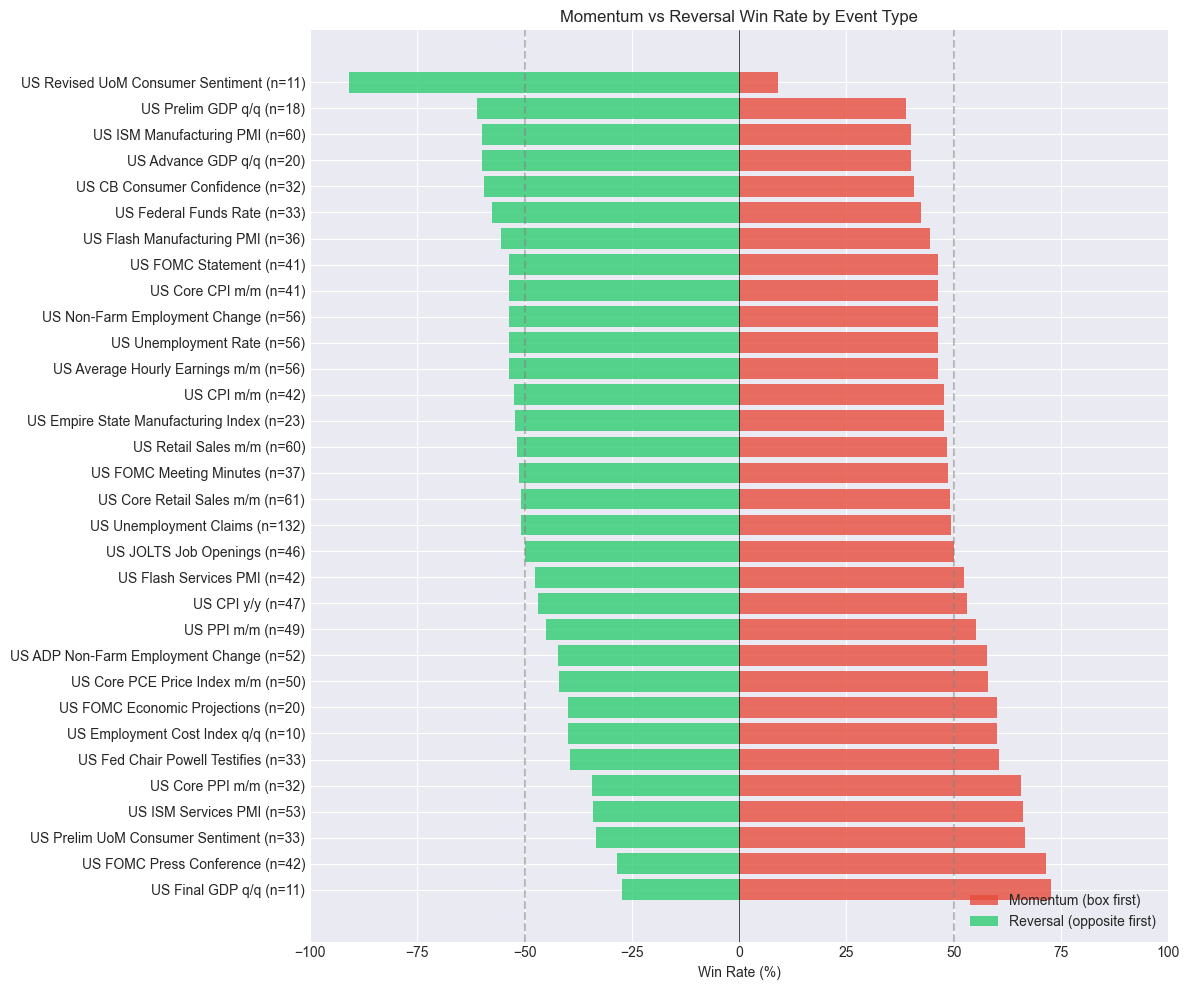

In [2]:
# Calculate win rates by event type
by_event = df.groupby('event_type').agg(
    total=('first_target_hit', 'count'),
    momentum_wins=('first_target_hit', lambda x: (x == 'box').sum()),
    reversal_wins=('first_target_hit', lambda x: (x == 'opposite').sum()),
).reset_index()

by_event['resolved'] = by_event['momentum_wins'] + by_event['reversal_wins']
by_event['momentum_rate'] = by_event['momentum_wins'] / by_event['resolved'] * 100
by_event['reversal_rate'] = by_event['reversal_wins'] / by_event['resolved'] * 100
by_event = by_event.sort_values('reversal_rate', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
y_pos = range(len(by_event))

ax.barh(y_pos, by_event['momentum_rate'], label='Momentum (box first)', color='#e74c3c', alpha=0.8)
ax.barh(y_pos, -by_event['reversal_rate'], label='Reversal (opposite first)', color='#2ecc71', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{e} (n={t})" for e, t in zip(by_event['event_type'], by_event['resolved'])])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Win Rate (%)')
ax.set_title('Momentum vs Reversal Win Rate by Event Type')
ax.legend(loc='lower right')
ax.set_xlim(-100, 100)

# Add 50% markers
ax.axvline(50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(-50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Win Rate by Release Time

In [1]:
# Filter to common release times
common_times = df['release_time'].value_counts()
common_times = common_times[common_times >= 10].index.tolist()

by_time = df[df['release_time'].isin(common_times)].groupby('release_time').agg(
    total=('first_target_hit', 'count'),
    momentum_wins=('first_target_hit', lambda x: (x == 'box').sum()),
    reversal_wins=('first_target_hit', lambda x: (x == 'opposite').sum()),
).reset_index()

by_time['resolved'] = by_time['momentum_wins'] + by_time['reversal_wins']
by_time['momentum_rate'] = by_time['momentum_wins'] / by_time['resolved'] * 100
by_time['reversal_rate'] = by_time['reversal_wins'] / by_time['resolved'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(by_time))
width = 0.35

ax.bar([i - width/2 for i in x], by_time['momentum_rate'], width, label='Momentum', color='#e74c3c')
ax.bar([i + width/2 for i in x], by_time['reversal_rate'], width, label='Reversal', color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n(n={n})" for t, n in zip(by_time['release_time'], by_time['resolved'])])
ax.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Momentum vs Reversal by Release Time')
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

## 3. Range Size vs Outcome

  range_quartile  avg_range  resolved  momentum_rate  reversal_rate
0  Q1 (smallest)   0.094850       352      55.965909      44.034091
1             Q2   0.193937       351      50.142450      49.857550
2             Q3   0.352602       345      52.463768      47.536232
3   Q4 (largest)   0.924807       287      44.599303      55.400697


C:\Users\Christ\AppData\Local\Temp\ipykernel_2996\864455990.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_range = df.groupby('range_quartile').agg(


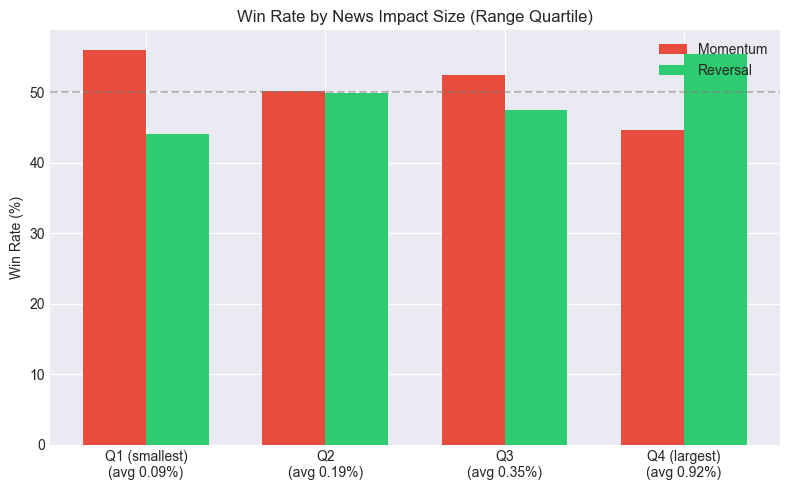

In [4]:
# Does larger range (more volatile news) favor momentum or reversal?
df['range_quartile'] = pd.qcut(df['range_pct'], 4, labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)'])

by_range = df.groupby('range_quartile').agg(
    total=('first_target_hit', 'count'),
    momentum_wins=('first_target_hit', lambda x: (x == 'box').sum()),
    reversal_wins=('first_target_hit', lambda x: (x == 'opposite').sum()),
    avg_range=('range_pct', 'mean'),
).reset_index()

by_range['resolved'] = by_range['momentum_wins'] + by_range['reversal_wins']
by_range['momentum_rate'] = by_range['momentum_wins'] / by_range['resolved'] * 100
by_range['reversal_rate'] = by_range['reversal_wins'] / by_range['resolved'] * 100

print(by_range[['range_quartile', 'avg_range', 'resolved', 'momentum_rate', 'reversal_rate']])

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(by_range))
width = 0.35

ax.bar([i - width/2 for i in x], by_range['momentum_rate'], width, label='Momentum', color='#e74c3c')
ax.bar([i + width/2 for i in x], by_range['reversal_rate'], width, label='Reversal', color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels([f"{q}\n(avg {r:.2f}%)" for q, r in zip(by_range['range_quartile'], by_range['avg_range'])])
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate by News Impact Size (Range Quartile)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. First Sweep Direction Analysis

In [5]:
# Does first sweep direction (high vs low) affect outcome?
by_sweep = df.groupby('first_sweep').agg(
    total=('first_target_hit', 'count'),
    momentum_wins=('first_target_hit', lambda x: (x == 'box').sum()),
    reversal_wins=('first_target_hit', lambda x: (x == 'opposite').sum()),
).reset_index()

by_sweep['resolved'] = by_sweep['momentum_wins'] + by_sweep['reversal_wins']
by_sweep['momentum_rate'] = by_sweep['momentum_wins'] / by_sweep['resolved'] * 100
by_sweep['reversal_rate'] = by_sweep['reversal_wins'] / by_sweep['resolved'] * 100

print("First sweep HIGH means price initially went UP")
print("First sweep LOW means price initially went DOWN")
print()
print(by_sweep[['first_sweep', 'resolved', 'momentum_rate', 'reversal_rate']])

First sweep HIGH means price initially went UP
First sweep LOW means price initially went DOWN

  first_sweep  resolved  momentum_rate  reversal_rate
0        high       712      48.735955      51.264045
1         low       623      53.772071      46.227929


## 5. MAE Distribution

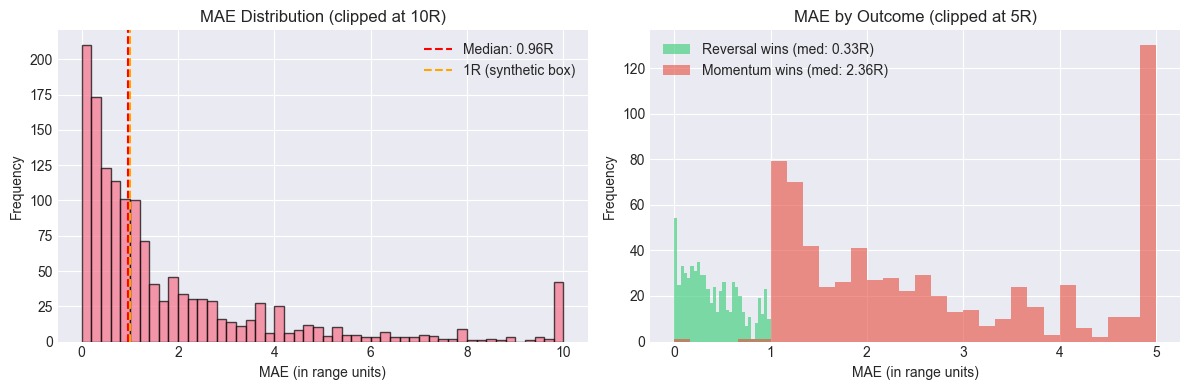

In [6]:
# MAE before reversal - how much pain do you have to endure?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall MAE distribution
ax1 = axes[0]
ax1.hist(df['mae_before_reversal'].clip(upper=10), bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(df['mae_before_reversal'].median(), color='red', linestyle='--', label=f"Median: {df['mae_before_reversal'].median():.2f}R")
ax1.axvline(1, color='orange', linestyle='--', label='1R (synthetic box)')
ax1.set_xlabel('MAE (in range units)')
ax1.set_ylabel('Frequency')
ax1.set_title('MAE Distribution (clipped at 10R)')
ax1.legend()

# MAE by outcome
ax2 = axes[1]
reversal_mae = df[df['first_target_hit'] == 'opposite']['mae_before_reversal']
momentum_mae = df[df['first_target_hit'] == 'box']['mae_before_reversal']

ax2.hist(reversal_mae.clip(upper=5), bins=30, alpha=0.6, label=f'Reversal wins (med: {reversal_mae.median():.2f}R)', color='#2ecc71')
ax2.hist(momentum_mae.clip(upper=5), bins=30, alpha=0.6, label=f'Momentum wins (med: {momentum_mae.median():.2f}R)', color='#e74c3c')
ax2.set_xlabel('MAE (in range units)')
ax2.set_ylabel('Frequency')
ax2.set_title('MAE by Outcome (clipped at 5R)')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Time to First Sweep vs Outcome

In [7]:
# Does fast sweep = momentum? slow sweep = reversal?
df['time_quartile'] = pd.qcut(df['time_to_first_sweep'], 4, labels=['Q1 (fastest)', 'Q2', 'Q3', 'Q4 (slowest)'])

by_timing = df.groupby('time_quartile').agg(
    total=('first_target_hit', 'count'),
    momentum_wins=('first_target_hit', lambda x: (x == 'box').sum()),
    reversal_wins=('first_target_hit', lambda x: (x == 'opposite').sum()),
    avg_time=('time_to_first_sweep', 'mean'),
).reset_index()

by_timing['resolved'] = by_timing['momentum_wins'] + by_timing['reversal_wins']
by_timing['momentum_rate'] = by_timing['momentum_wins'] / by_timing['resolved'] * 100
by_timing['reversal_rate'] = by_timing['reversal_wins'] / by_timing['resolved'] * 100

print(by_timing[['time_quartile', 'avg_time', 'resolved', 'momentum_rate', 'reversal_rate']])

ValueError: Bin edges must be unique: Index([1.0, 1.0, 1.0, 3.0, 128.0], dtype='float64', name='time_to_first_sweep').
You can drop duplicate edges by setting the 'duplicates' kwarg

## 7. Deep Dive: Single Event Type

In [8]:
# Pick an event to analyze
EVENT = 'US Non-Farm Employment Change'  # <-- CHANGE THIS

event_df = df[df['event_type'] == EVENT].copy()
print(f"\n=== {EVENT} ===")
print(f"Total samples: {len(event_df)}")

resolved = event_df[event_df['first_target_hit'].notna()]
momentum = (resolved['first_target_hit'] == 'box').sum()
reversal = (resolved['first_target_hit'] == 'opposite').sum()
print(f"Momentum wins: {momentum} ({momentum/len(resolved)*100:.1f}%)")
print(f"Reversal wins: {reversal} ({reversal/len(resolved)*100:.1f}%)")
print(f"\nMedian MAE: {event_df['mae_before_reversal'].median():.2f}R")
print(f"Avg time to first sweep: {event_df['time_to_first_sweep'].mean():.1f} min")

# First sweep direction for this event
print(f"\nFirst sweep direction:")
print(event_df['first_sweep'].value_counts())


=== US Non-Farm Employment Change ===
Total samples: 61
Momentum wins: 26 (46.4%)
Reversal wins: 30 (53.6%)

Median MAE: 0.87R
Avg time to first sweep: 6.9 min

First sweep direction:
first_sweep
high    36
low     25
Name: count, dtype: int64


## 8. Interactive Filter

In [10]:
# Filter and see results
# Modify these filters as needed

filtered = df[
    # (df['event_type'] == 'US CPI m/m') &
    # (df['release_time'] == '08:30') &
    # (df['first_sweep'] == 'high') &
    # (df['range_pct'] > 0.05) &  # Filter by range size
    (df['first_target_hit'].notna())  # Only resolved trades
].copy()

print(f"Filtered: {len(filtered)} events")

momentum = (filtered['first_target_hit'] == 'box').sum()
reversal = (filtered['first_target_hit'] == 'opposite').sum()
total = momentum + reversal

print(f"\nMomentum: {momentum} ({momentum/total*100:.1f}%)")
print(f"Reversal: {reversal} ({reversal/total*100:.1f}%)")
print(f"\nMedian MAE: {filtered['mae_before_reversal'].median():.2f}R")

Filtered: 1335 events

Momentum: 682 (51.1%)
Reversal: 653 (48.9%)

Median MAE: 1.03R


## 9. Summary Table: All Events

In [11]:
# Full summary table
summary = df.groupby('event_type').agg(
    n=('first_target_hit', 'count'),
    momentum=('first_target_hit', lambda x: (x == 'box').sum()),
    reversal=('first_target_hit', lambda x: (x == 'opposite').sum()),
    avg_mae=('mae_before_reversal', 'mean'),
    median_mae=('mae_before_reversal', 'median'),
    avg_time_to_sweep=('time_to_first_sweep', 'mean'),
    avg_range_pct=('range_pct', 'mean'),
).reset_index()

summary['resolved'] = summary['momentum'] + summary['reversal']
summary['momentum_rate'] = (summary['momentum'] / summary['resolved'] * 100).round(1)
summary['reversal_rate'] = (summary['reversal'] / summary['resolved'] * 100).round(1)
summary['edge'] = abs(summary['momentum_rate'] - 50).round(1)  # Distance from 50%

summary = summary.sort_values('edge', ascending=False)
summary[['event_type', 'n', 'momentum_rate', 'reversal_rate', 'edge', 'median_mae', 'avg_time_to_sweep', 'avg_range_pct']]

,event_type,n,momentum_rate,reversal_rate,edge,median_mae,avg_time_to_sweep,avg_range_pct
29,US Revised UoM Consumer Sentiment,11,9.1,90.9,40.9,0.480519,1.363636,0.165263
18,US Final GDP q/q,11,72.7,27.3,22.7,3.068493,2.272727,0.164651
14,US FOMC Press Conference,42,71.4,28.6,21.4,1.812411,1.214286,0.164733
27,US Prelim UoM Consumer Sentiment,33,66.7,33.3,16.7,1.802198,3.424242,0.316924
22,US ISM Services PMI,53,66.0,34.0,16.0,1.392818,3.129630,0.265098
8,US Core PPI m/m,32,65.6,34.4,15.6,1.792000,16.121212,0.367601
26,US Prelim GDP q/q,18,38.9,61.1,11.1,0.785400,3.166667,0.172782
16,US Fed Chair Powell Testifies,33,60.6,39.4,10.6,1.251613,1.969697,0.188401
11,US Employment Cost Index q/q,10,60.0,40.0,10.0,4.295129,5.500000,0.225110
21,US ISM Manufacturing PMI,60,40.0,60.0,10.0,0.635987,2.050000,0.276910
